# Microscope parameters optimization

The goal of this notebook is to help in the optimization of microscope parameters, such as the objective size or the zstep size.

In [1]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience
from pathlib import Path
from scipy.stats import linregress

import warnings

import sys

my_path = Path.cwd().parent.parent / "src"
sys.path.append(str(my_path))

from visualization import visualization
from utils import utils

%matplotlib inline

## Paths definition

In [ ]:
ROOT = Path(r"K:\users\voland\data\current\TgCetnEos_CenSpark_H2B_4h-24h-48hpf\20260505CFHa_CetnGFP_CS_4hpf")

PATH_4HPF_1E1B_25X = ROOT/"1e1b_25X_TL-1"/"20260505CFHa_CetnGFP_CS_4hpf.lif - 1e1b_25X_TL-1.tif"

PATH_4HPF_1E2_63X =  ROOT/"1e2_63x_TL-1"/"original"/"20260505CFHa_CetnGFP_CS_4hpf.lif - 1e2_63x_TL-1.tif"
PATH_4HPF_1E3_63X = ROOT/"1e3_63x_TL"/"20260505CFHa_CetnGFP_CS_4hpf.lif - 1e3_63x_TL.tif"
PATH_4HPF_1E4_63X = ROOT/"1e4_63x_TL"/"20260505CFHa_CetnGFP_CS_4hpf.lif - 1e4_63x_TL.tif"

PATH_4HPF_25X = [PATH_4HPF_1E1B_25X]
PATH_4HPF_63X = [PATH_4HPF_1E2_63X,PATH_4HPF_1E3_63X,PATH_4HPF_1E4_63X]

## Utilitary function definitions

In [3]:
def temportal_mean_intensity(vol, channel_id):
    intensities = np.mean(vol[:,:,channel_id], axis=(1, 2, 3))
    return intensities

In [4]:
def depth_mean_intensity(frame, channel_id):
    intensities = np.mean(frame[:,channel_id], axis=(2, 3))
    return intensities

In [ ]:
def plot_temporal_mean_intensity(VOL_PATHS):
    fig = plt.figure(figsize=(10, 4 * len(VOL_PATHS)))

    slopes_ct = []
    slopes_cs = []
    for idx, VOL_PATH in enumerate(VOL_PATHS, start=1):
        vol = tifffile.imread(VOL_PATH)

        with tifffile.TiffFile(VOL_PATH) as tif:
            imagej_metadata = tif.imagej_metadata
            t_interval =  imagej_metadata["finterval"]

        timelapse = np.arange(vol.shape[0]) * t_interval
        mean_intensity_ct = temportal_mean_intensity(vol, 0)
        mean_intensity_cs = temportal_mean_intensity(vol, 1)

        ax = fig.add_subplot(len(VOL_PATHS), 1, idx)
        ax.plot(timelapse, mean_intensity_ct, label=f'Cent2 (slope={linregress(timelapse, mean_intensity_ct).slope:.3e})')
        ax.plot(timelapse, mean_intensity_cs, label=f'CenSpark (slope={linregress(timelapse, mean_intensity_cs).slope:.3e})')
        ax.set_title(f'{VOL_PATH.name}')
        ax.set_xlabel('Time [s]')
        ax.set_ylabel('Mean intensity')
        ax.legend()
        ax.grid(True)

        slope_ct, intercept_ct, r_ct, p_ct, se_ct = linregress(timelapse, mean_intensity_ct)
        slope_cs, intercept_cs, r_cs, p_cs, se_cs = linregress(timelapse, mean_intensity_cs)

        slopes_ct.append(slope_ct)
        slopes_cs.append(slope_cs)
    return np.array(slopes_ct), np.array(slopes_cs)

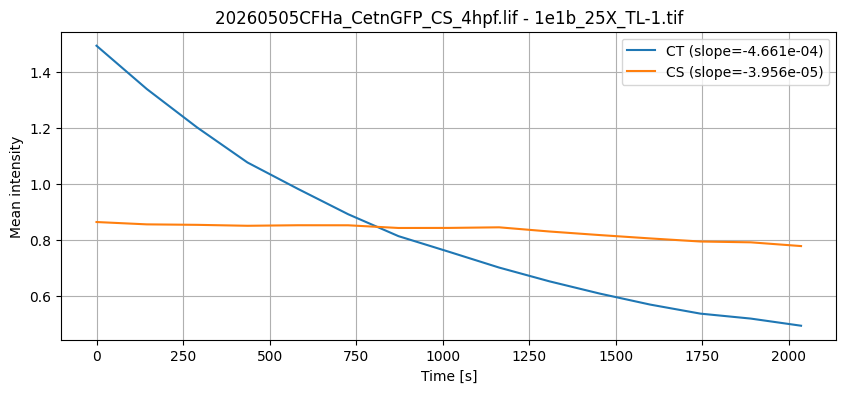

In [6]:
slopes_ct_4hpf_25x, slopes_cs_4hpf_25x = plot_temporal_mean_intensity(PATH_4HPF_25X)

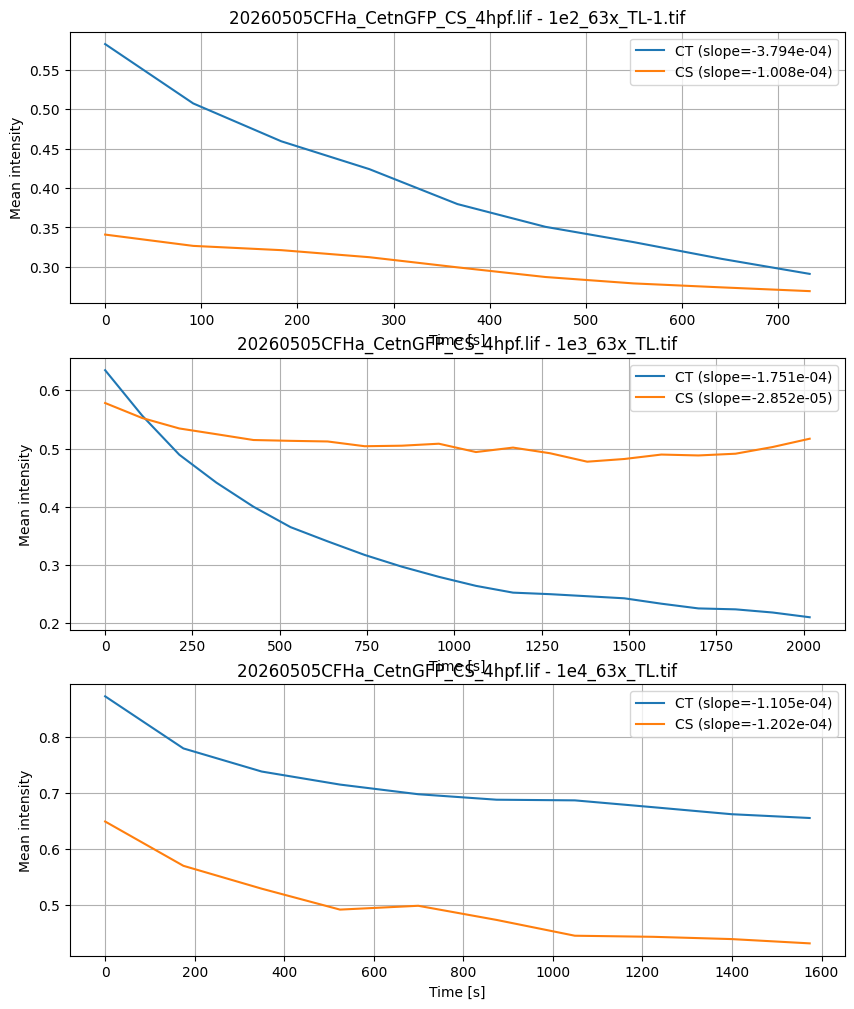

In [7]:
slopes_ct_4hpf_63x, slopes_cs_4hpf_63x = plot_temporal_mean_intensity(PATH_4HPF_63X)

([<matplotlib.axis.XTick at 0x1f8d45a39d0>,
 [Text(1, 0, '25x'), Text(2, 0, '63x')])

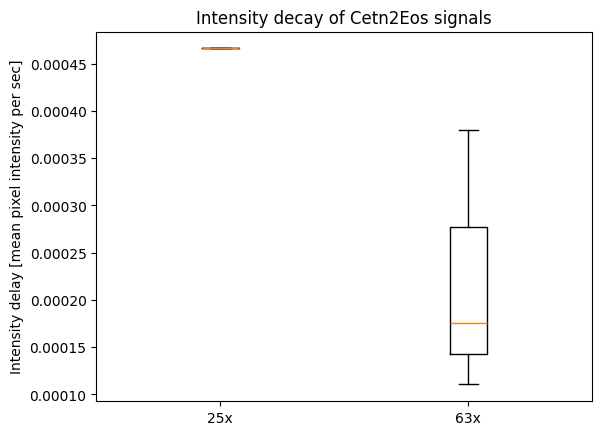

In [8]:
plt.boxplot([-1*slopes_ct_4hpf_25x,-1*slopes_ct_4hpf_63x])
plt.title("Intensity decay of Cetn2Eos signals")
plt.ylabel("Intensity delay [mean pixel intensity per sec]")
plt.xticks([1, 2], ['25x', '63x'])

([<matplotlib.axis.XTick at 0x1f8d4648f40>,
 [Text(1, 0, '25x'), Text(2, 0, '63x')])

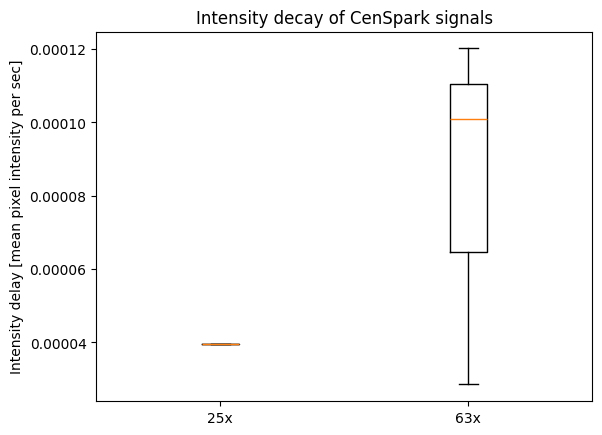

In [9]:
plt.boxplot([-1*slopes_cs_4hpf_25x,-1*slopes_cs_4hpf_63x])
plt.title("Intensity decay of CenSpark signals")
plt.ylabel("Intensity delay [mean pixel intensity per sec]")
plt.xticks([1, 2], ['25x', '63x'])

In [10]:
vol1 = tifffile.memmap(PATH_4HPF_1E1B_25X)

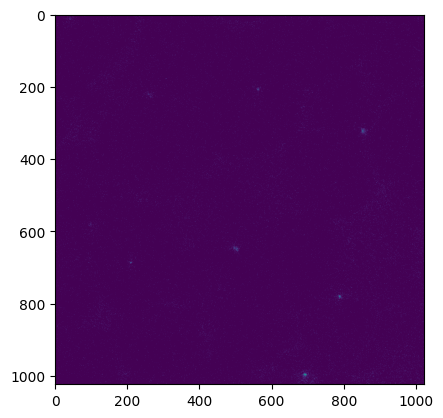

In [15]:
img = vol1[8,43,1].astype(np.uint8)
plt.imshow(img)

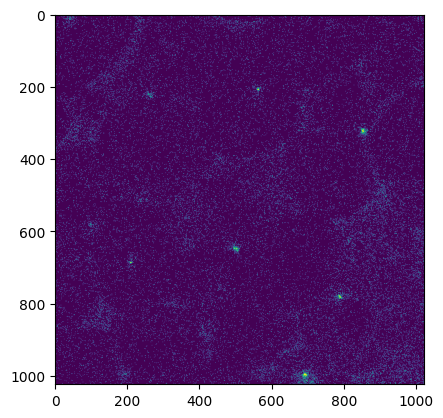

In [38]:
equ_img = cv2.equalizeHist(img)
plt.imshow(equ_img)

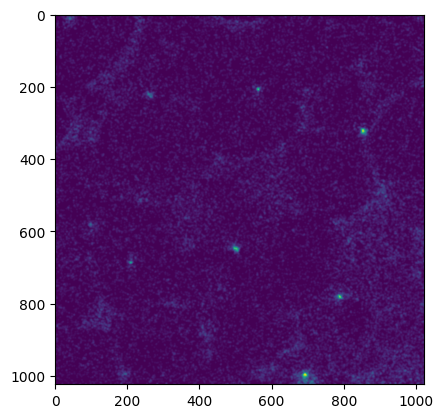

In [46]:
import cv2
from scipy import ndimage
import skimage as ski

equ = ndimage.gaussian_filter(equ_img,sigma=2)
plt.imshow(equ)

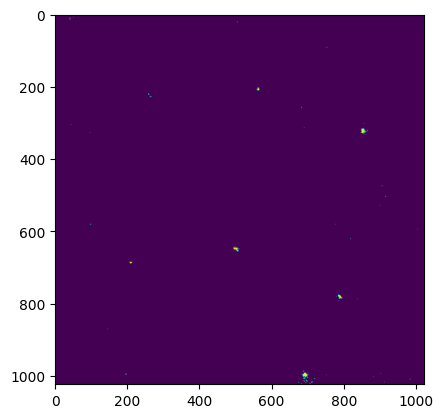

In [ ]:
footprint = ski.morphology.disk(1)

equ = ndimage.median_filter(equ_img,size=3)
plt.imshow(equ)